# Importing all essential libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\practice files\Zomato-data- (1).csv")

In [3]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


# Problem:
- What type of restaurants perform better?

- What factors affect ratings?

- What pricing strategy works best?

- What services (online order, table booking) increase ratings or popularity?

 How to improve customer satisfaction?

In [4]:
df.shape

(148, 7)

In [5]:
df.head()         # looking into the columns ,which columns can effect business decisions.

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [6]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


**numerical columns**- votes,approx_cost


**categorical columns**- online_order,book_table,rate,listed_in(type)

# renaming the approx cost and  listed in type column name so that they could be more understandable from their name itself

In [7]:
df.rename(columns={'approx_cost(for two people)': 'cost_for_two','listed_in(type)':'service_type','rate':'rating by 5'}, inplace=True)

In [8]:
df

,name,online_order,book_table,rating by 5,votes,cost_for_two,service_type
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [23]:
# rating column looks untidy removing /5 from it.

In [25]:
df['rating by 5'] = df['rating by 5'].str.replace('/5','')

df['rating by 5'] = pd.to_numeric(df['rating by 5'], errors='coerce')

In [26]:
df

,name,online_order,book_table,rating by 5,votes,cost_for_two,service_type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


# now finding the missing values

In [9]:
df.isnull().sum()

name            0
online_order    0
book_table      0
rating by 5     0
votes           0
cost_for_two    0
service_type    0
dtype: int64

In [10]:
# the data is already clean ,there are  no null values in the data.

In [27]:
df.duplicated().sum()

0

In [28]:
df[df.duplicated()]

,name,online_order,book_table,rating by 5,votes,cost_for_two,service_type


Duplicate values were checked in the dataset. Although some repeated values may occur naturally (e.g., restaurants with similar attributes), no problematic duplicate records were found.

In [30]:
df.columns

Index(['name', 'online_order', 'book_table', 'rating by 5', 'votes',
       'cost_for_two', 'service_type'],
      dtype='object')

# Univariate Analysis

In [12]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

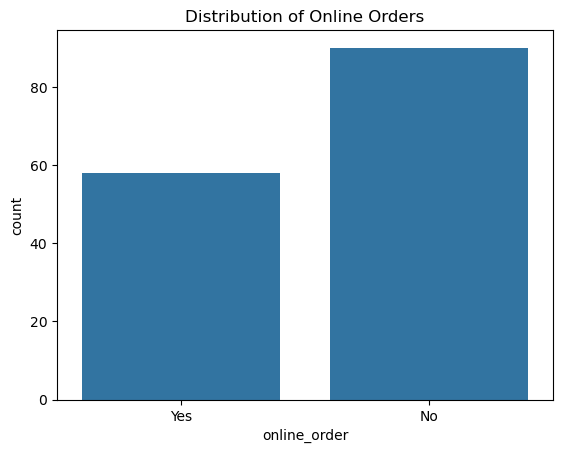

In [13]:
sns.countplot(data=df, x='online_order')
plt.title('Distribution of Online Orders')
plt.show()

In [14]:
df['online_order'].value_counts(normalize=True) * 100

online_order
No     60.810811
Yes    39.189189
Name: proportion, dtype: float64

In [15]:
#  from above we got to know that still most of the people prefer comming to the restrua itself.

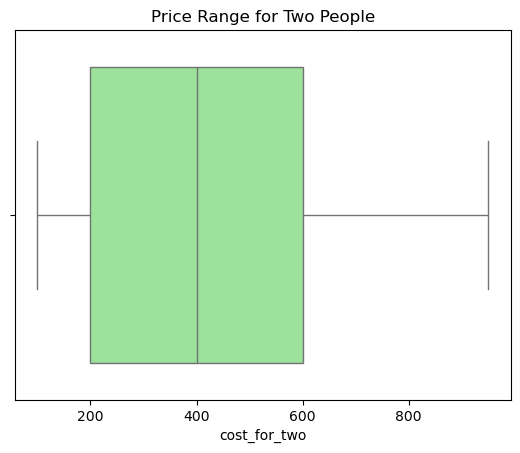

In [16]:
sns.boxplot(x=df['cost_for_two'], color='lightgreen')
plt.title('Price Range for Two People')
plt.show()

In [17]:
# The median cost for two is 400,and for the ultra luxury the price is somewhere around 1000.

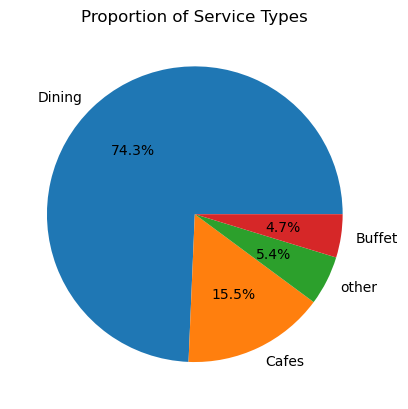

In [18]:
df['service_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Service Types')
plt.ylabel('') 
plt.show()

In [19]:
# The most common service type is dinig, accounting for 74.3% of the total.

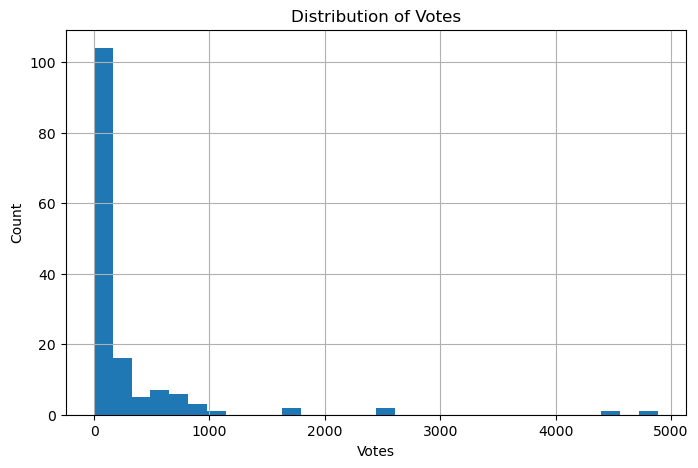

In [33]:
plt.figure(figsize=(8,5))

df['votes'].hist(bins=30)

plt.title("Distribution of Votes")

plt.xlabel("Votes")
plt.ylabel("Count")

plt.show()

In [35]:
# Most restaurants have low to moderate votes.

# A few restaurants have very high votes.

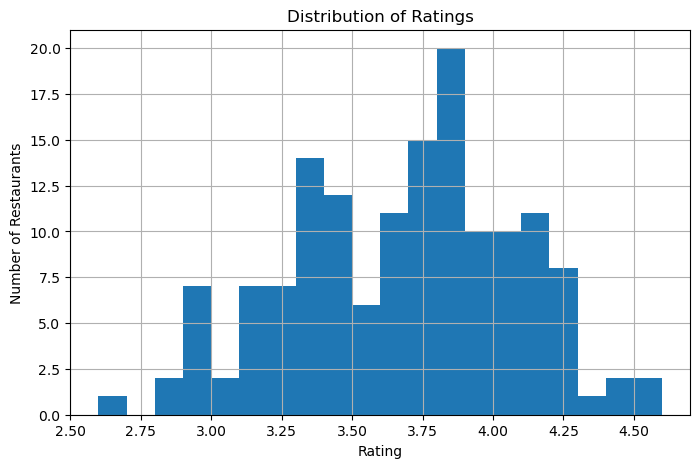

In [31]:
plt.figure(figsize=(8,5))

df['rating by 5'].hist(bins=20)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

In [32]:
# Very few restaurants have ratings below 3, suggesting that poorly rated restaurants are uncommon.

# Bivariate Analysis

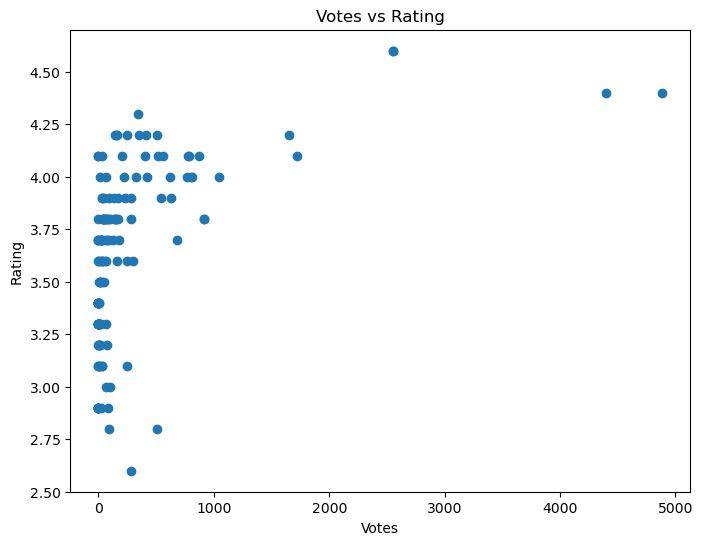

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(df['votes'], df['rating by 5'])

plt.xlabel("Votes")
plt.ylabel("Rating")

plt.title("Votes vs Rating")

plt.show()

Votes and ratings are weakly positively correlated

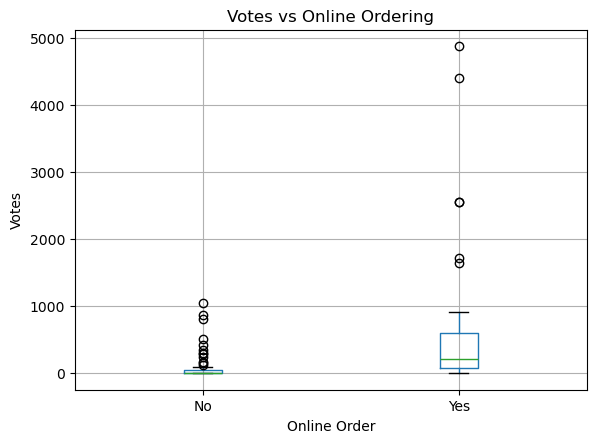

In [50]:
df.boxplot(column='votes', by='online_order')

plt.title("Votes vs Online Ordering")

plt.xlabel("Online Order")
plt.ylabel("Votes")

plt.suptitle("")

plt.show()

In [ ]:
# restaurants with online ordering get more votes

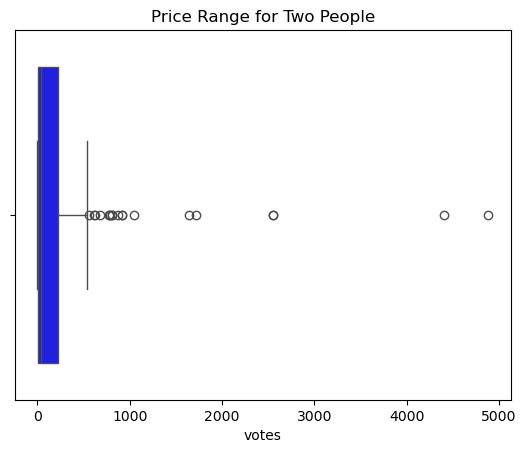

In [34]:
sns.boxplot(x=df['votes'], color='blue')
plt.title('Price Range for Two People')
plt.show()

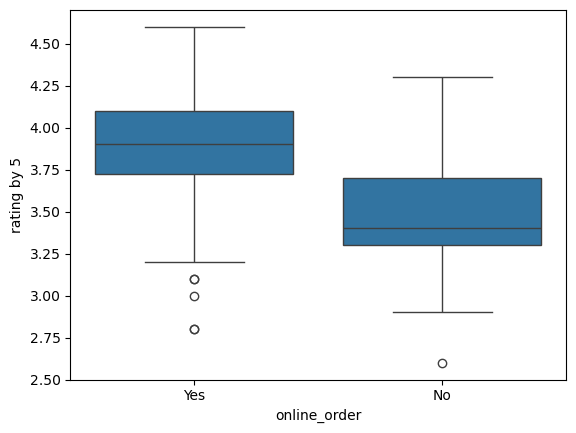

In [38]:
sns.boxplot(x='online_order', y='rating by 5', data=df)
plt.show()

In [39]:
top10_votes = df.sort_values(by='votes', ascending=False).head(10)

print(top10_votes[['name','votes']])

                  name  votes
38   Empire Restaurant   4884
86       Meghana Foods   4401
7               Onesta   2556
44              Onesta   2556
65         Kabab Magic   1720
37     Szechuan Dragon   1647
54        Roving Feast   1047
14     San Churro Cafe    918
2      San Churro Cafe    918
67  Gustoes Beer House    868


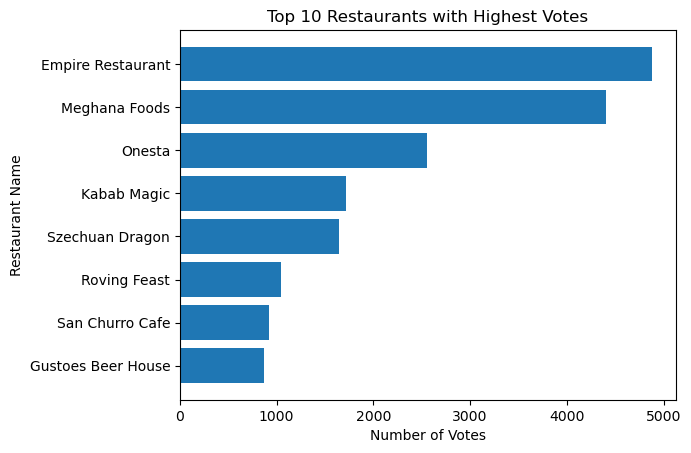

In [40]:
plt.barh(top10_votes['name'], top10_votes['votes'])

plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Name")
plt.title("Top 10 Restaurants with Highest Votes")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# these are the top 10 restaurants with  high number of votes.

In [55]:
top_ratings=df.sort_values('rating by 5', ascending=False).head(5)
top_ratings

,name,online_order,book_table,rating by 5,votes,cost_for_two,service_type
44,Onesta,Yes,Yes,4.6,2556,600,other
7,Onesta,Yes,Yes,4.6,2556,600,Cafes
38,Empire Restaurant,Yes,No,4.4,4884,750,other
86,Meghana Foods,Yes,No,4.4,4401,600,Dining
52,Corner House Ice Cream,No,No,4.3,345,400,Dining


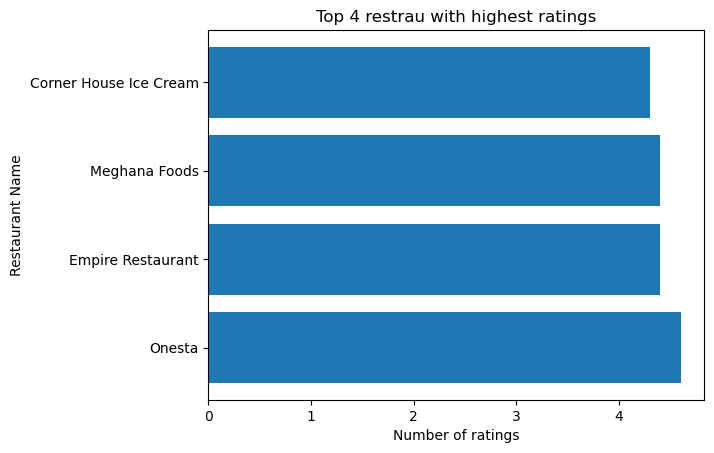

In [60]:
plt.barh(top_ratings['name'], top_ratings['rating by 5'])

plt.xlabel("Number of ratings")
plt.ylabel("Restaurant Name")
plt.title("Top 4 restrau with highest ratings")

plt.show()

# report

This dataset contains information about restaurants including their ratings by 5, votes, online ordering availability, table booking facility, approximate cost for two people, and restaurant type.

The objective of this is to understand restaurant popularity, customer preferences, and the factors that influence restaurant ratings and engagement.


During the preprocessing stage, the rating column contained values such as "4.1/5". The "/5" part was removed and the column was converted into a numeric format for proper analysis,and also many columns  were renamed for better understanding .

The analysis of restaurant ratings shows that most restaurants have ratings between 3.5 and 4.2, indicating generally positive customer satisfaction. However, only a small number of restaurants achieve ratings above 4.5.

The vote distribution reveals that restaurant popularity is uneven, with a few restaurants receiving significantly higher engagement compared to others.

Among the restaurant categories, the "Dining" segment appears to dominate the dataset with apprx 75% of total.

Restaurants offering online ordering tend to receive higher vote counts. This suggests that online accessibility may contribute to increased customer interaction and popularity.

Ratings and votes play a significant role in identifying successful restaurants, while service features such as online ordering can enhance customer engagement.